# Robust 250ms Balanced Audio Dataset Builder

This notebook extracts a **perfectly balanced**, **perfectly sized** dataset for gunshot detection.

## What it does
1. **Class 1 (Gunshot)**: Reads every `.wav` from `Data/gun` and `Data/edge-collected-gunshot-audio`. Uses **onset detection** to find the exact gunshot spike and cuts a perfect 250ms window around it.
2. **Class 0 (Non-Gunshot)**: Reads every `.wav` from `Data/sound` AND `Data/audio`. Uses a **sliding window with 50% overlap** (125ms hop) to chop them into 250ms clips.
3. **Every single output file is EXACTLY 250ms** — no exceptions.
4. **Perfect 1:1 balance** — whichever class has fewer clips, the other is randomly downsampled to match.
5. Output goes into exactly **2 folders**: `class_1_gunshot/` and `class_0_nongunshot/`.

## Data Sources
| Class | Folder | Files |
|-------|--------|-------|
| 1 (Gunshot) | `Data/gun` | ~2,403 |
| 1 (Gunshot) | `Data/edge-collected-gunshot-audio` | ~2,148 |
| 0 (Non-Gunshot) | `Data/sound` | ~230 |
| 0 (Non-Gunshot) | `Data/audio` | ~6,000 |

In [1]:
%pip install -q librosa soundfile pandas numpy tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import soundfile as sf
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
import json
import shutil
import random

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

c:\ProgramData\anaconda3\envs\guns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ==========================================================
# CONFIGURATION — Change these if needed
# ==========================================================
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'Data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'Data'
OUTPUT_DIR = DATA_DIR / 'TRIMMED_250MS_STRICT'

SAMPLE_RATE = 22050           # All audio resampled to this
TARGET_MS = 250               # Every clip will be EXACTLY this long
TARGET_SAMPLES = int(SAMPLE_RATE * TARGET_MS / 1000)  # = 5512 samples

PRE_EVENT_MS = 50             # For gunshots: grab 50ms BEFORE the bang
PRE_EVENT_SAMPLES = int(SAMPLE_RATE * PRE_EVENT_MS / 1000)

CLASS0_HOP_MS = 125           # For background: slide by 125ms (50% overlap)
CLASS0_HOP_SAMPLES = int(SAMPLE_RATE * CLASS0_HOP_MS / 1000)

# Source directories
CLASS1_DIRS = [DATA_DIR / 'gun', DATA_DIR / 'edge-collected-gunshot-audio']
CLASS0_DIRS = [DATA_DIR / 'sound', DATA_DIR / 'audio']

print(f'Project Root   : {PROJECT_ROOT}')
print(f'Data Directory : {DATA_DIR}')
print(f'Output         : {OUTPUT_DIR}')
print(f'Clip Duration  : {TARGET_MS}ms = {TARGET_SAMPLES} samples @ {SAMPLE_RATE}Hz')

Project Root   : C:\order\Desktop\Data-Cleaner
Data Directory : C:\order\Desktop\Data-Cleaner\Data
Output         : C:\order\Desktop\Data-Cleaner\Data\TRIMMED_250MS_STRICT
Clip Duration  : 250ms = 5512 samples @ 22050Hz


In [4]:
# ==========================================================
# HELPER FUNCTIONS
# ==========================================================
def load_audio(path):
    """Load a WAV file, resample to SAMPLE_RATE, convert to mono."""
    try:
        y, _ = librosa.load(str(path), sr=SAMPLE_RATE, mono=True)
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
        return y.astype(np.float32)
    except Exception:
        return None


def force_exact_length(clip):
    """Guarantee the clip is EXACTLY TARGET_SAMPLES long. No exceptions."""
    if len(clip) == TARGET_SAMPLES:
        return clip
    if len(clip) > TARGET_SAMPLES:
        return clip[:TARGET_SAMPLES]
    # Pad with zeros if too short
    return np.pad(clip, (0, TARGET_SAMPLES - len(clip)), mode='constant')


def normalize_clip(clip):
    """Normalize to prevent clipping, preserve dynamics."""
    peak = np.max(np.abs(clip))
    if peak > 0.99:
        clip = (clip / peak) * 0.99
    return clip.astype(np.float32)


def write_clip(path, clip):
    """Write a clip to disk as 16-bit PCM WAV."""
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), clip, SAMPLE_RATE, subtype='PCM_16')


def is_junk(path):
    """Skip macOS junk files."""
    return '__MACOSX' in str(path) or path.name.startswith('._')


def collect_wavs(dirs):
    """Collect all .wav files from a list of directories."""
    files = []
    for d in dirs:
        if d.exists():
            files.extend([f for f in d.rglob('*.wav') if not is_junk(f)])
    return sorted(files)

In [5]:
# ==========================================================
# CLASS 1 EXTRACTION: Onset Detection (Sniper Method)
# ==========================================================
def extract_gunshot_clips(y):
    """
    Find gunshot onsets using librosa, then cut a 250ms window
    starting 50ms BEFORE each onset.
    
    Returns a list of numpy arrays, each exactly TARGET_SAMPLES long.
    """
    if y is None or len(y) < 100:
        return []
    
    # Detect onsets (sudden energy spikes)
    onset_frames = librosa.onset.onset_detect(
        y=y, sr=SAMPLE_RATE, backtrack=False,
        delta=0.1, wait=2
    )
    onset_samples = librosa.frames_to_samples(onset_frames)
    
    # Fallback: if no onset detected, use the loudest point
    if len(onset_samples) == 0:
        onset_samples = [int(np.argmax(np.abs(y)))]
    
    # Remove overlapping onsets (keep minimum gap of half a window)
    min_gap = TARGET_SAMPLES // 2
    filtered = []
    for onset in sorted(onset_samples):
        if not filtered or (onset - filtered[-1]) >= min_gap:
            filtered.append(onset)
    
    clips = []
    for onset in filtered:
        # Start 50ms before the bang
        start = int(onset) - PRE_EVENT_SAMPLES
        end = start + TARGET_SAMPLES
        
        # Handle edge cases (clip near start/end of file)
        pad_left = max(0, -start)
        pad_right = max(0, end - len(y))
        src_start = max(0, start)
        src_end = min(len(y), end)
        
        clip = y[src_start:src_end]
        if pad_left > 0 or pad_right > 0:
            clip = np.pad(clip, (pad_left, pad_right), mode='constant')
        
        clip = force_exact_length(clip)
        clip = normalize_clip(clip)
        
        # Only keep if there's actual sound (not digital silence)
        if np.max(np.abs(clip)) > 0.01:
            clips.append(clip)
    
    return clips

In [6]:
# ==========================================================
# CLASS 0 EXTRACTION: Sliding Window with 50% Overlap
# ==========================================================
def extract_background_clips(y):
    """
    Cut the audio into overlapping 250ms windows (125ms hop).
    Skip windows that look suspiciously impulsive (might be a gunshot).
    
    Returns a list of numpy arrays, each exactly TARGET_SAMPLES long.
    """
    if y is None or len(y) < 100:
        return []
    
    clips = []
    
    # If the file is shorter than 250ms, pad it
    if len(y) < TARGET_SAMPLES:
        clip = force_exact_length(y)
        clip = normalize_clip(clip)
        if np.max(np.abs(clip)) > 0.003:  # Not pure silence
            clips.append(clip)
        return clips
    
    # Slide through with 50% overlap
    for start in range(0, len(y) - TARGET_SAMPLES + 1, CLASS0_HOP_SAMPLES):
        end = start + TARGET_SAMPLES
        clip = y[start:end]
        clip = force_exact_length(clip)  # Safety guarantee
        
        # Check if this window is suspiciously impulsive
        peak = np.max(np.abs(clip))
        rms = np.sqrt(np.mean(clip ** 2) + 1e-10)
        crest = peak / rms
        
        # Skip if it looks like a gunshot sneaked into the background
        if crest > 8.5 and peak > 0.1:
            continue
        
        # Skip pure silence
        if peak < 0.003:
            continue
        
        clip = normalize_clip(clip)
        clips.append(clip)
    
    return clips

In [7]:
# ==========================================================
# BUILD THE DATASET
# ==========================================================
def build_dataset():
    # Clean slate
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
    
    c1_dir = OUTPUT_DIR / 'class_1_gunshot'
    c0_dir = OUTPUT_DIR / 'class_0_nongunshot'
    reports_dir = OUTPUT_DIR / 'reports'
    c1_dir.mkdir(parents=True)
    c0_dir.mkdir(parents=True)
    reports_dir.mkdir(parents=True)
    
    # ---- STEP 1: Extract ALL Class 1 clips ----
    c1_files = collect_wavs(CLASS1_DIRS)
    print(f'Class 1 source files found: {len(c1_files)}')
    
    all_c1_clips = []  # list of (clip_array, source_file_str)
    for f in tqdm(c1_files, desc='Extracting Class 1 (Gunshots)'):
        y = load_audio(f)
        if y is None:
            continue
        clips = extract_gunshot_clips(y)
        for clip in clips:
            all_c1_clips.append((clip, str(f.relative_to(PROJECT_ROOT))))
    
    print(f'Total Class 1 clips extracted: {len(all_c1_clips)}')
    
    # ---- STEP 2: Extract ALL Class 0 clips ----
    c0_files = collect_wavs(CLASS0_DIRS)
    print(f'Class 0 source files found: {len(c0_files)}')
    
    all_c0_clips = []  # list of (clip_array, source_file_str)
    for f in tqdm(c0_files, desc='Extracting Class 0 (Non-Gunshots)'):
        y = load_audio(f)
        if y is None:
            continue
        clips = extract_background_clips(y)
        for clip in clips:
            all_c0_clips.append((clip, str(f.relative_to(PROJECT_ROOT))))
    
    print(f'Total Class 0 clips extracted: {len(all_c0_clips)}')
    
    # ---- STEP 3: Balance the dataset (1:1) ----
    min_count = min(len(all_c1_clips), len(all_c0_clips))
    print(f'\nBalancing to {min_count} clips per class...')
    
    # Shuffle and trim to equal size
    random.shuffle(all_c1_clips)
    random.shuffle(all_c0_clips)
    all_c1_clips = all_c1_clips[:min_count]
    all_c0_clips = all_c0_clips[:min_count]
    
    # ---- STEP 4: Write to disk ----
    manifest = []
    
    for i, (clip, src) in enumerate(tqdm(all_c1_clips, desc='Writing Class 1')):
        name = f'c1_{i+1:06d}.wav'
        path = c1_dir / name
        write_clip(path, clip)
        manifest.append({'label': 1, 'split': 'class_1_gunshot',
                         'file': f'class_1_gunshot/{name}', 'source': src})
    
    for i, (clip, src) in enumerate(tqdm(all_c0_clips, desc='Writing Class 0')):
        name = f'c0_{i+1:06d}.wav'
        path = c0_dir / name
        write_clip(path, clip)
        manifest.append({'label': 0, 'split': 'class_0_nongunshot',
                         'file': f'class_0_nongunshot/{name}', 'source': src})
    
    # ---- STEP 5: Save reports ----
    df = pd.DataFrame(manifest)
    df.to_csv(reports_dir / 'manifest.csv', index=False)
    
    summary = {
        'class_1_clips': min_count,
        'class_0_clips': min_count,
        'total_clips': min_count * 2,
        'clip_duration_ms': TARGET_MS,
        'sample_rate': SAMPLE_RATE,
        'samples_per_clip': TARGET_SAMPLES
    }
    (reports_dir / 'summary.json').write_text(json.dumps(summary, indent=2))
    
    print(f'\n{"=" * 50}')
    print(f'DATASET BUILD COMPLETE')
    print(f'{"=" * 50}')
    print(f'Class 1 (Gunshot)     : {min_count:,} clips')
    print(f'Class 0 (Non-Gunshot) : {min_count:,} clips')
    print(f'Total                 : {min_count * 2:,} clips')
    print(f'Each clip             : exactly {TARGET_MS}ms ({TARGET_SAMPLES} samples)')
    print(f'Output                : {OUTPUT_DIR}')
    print(f'{"=" * 50}')
    
    return df

In [8]:
# Run the build!
manifest_df = build_dataset()

Class 1 source files found: 4138


Extracting Class 1 (Gunshots): 100%|██████████| 4138/4138 [00:29<00:00, 138.73it/s]


Total Class 1 clips extracted: 11473
Class 0 source files found: 6230


Extracting Class 0 (Non-Gunshots): 100%|██████████| 6230/6230 [02:37<00:00, 39.61it/s] 


Total Class 0 clips extracted: 196034

Balancing to 11473 clips per class...


Writing Class 0: 100%|██████████| 11473/11473 [00:17<00:00, 649.38it/s]



DATASET BUILD COMPLETE
Class 1 (Gunshot)     : 11,473 clips
Class 0 (Non-Gunshot) : 11,473 clips
Total                 : 22,946 clips
Each clip             : exactly 250ms (5512 samples)
Output                : C:\order\Desktop\Data-Cleaner\Data\TRIMMED_250MS_STRICT


In [9]:
# ==========================================================
# VERIFICATION: Check that every file is exactly 250ms
# ==========================================================
print('Verifying all output files...')
c1_files = list((OUTPUT_DIR / 'class_1_gunshot').glob('*.wav'))
c0_files = list((OUTPUT_DIR / 'class_0_nongunshot').glob('*.wav'))

bad_files = []
for f in tqdm(c1_files + c0_files, desc='Checking sizes'):
    y, sr = librosa.load(f, sr=None)
    if len(y) != TARGET_SAMPLES:
        bad_files.append((f.name, len(y)))

if bad_files:
    print(f'WARNING: {len(bad_files)} files are NOT exactly {TARGET_SAMPLES} samples!')
    for name, length in bad_files[:10]:
        print(f'  {name}: {length} samples')
else:
    print(f'ALL {len(c1_files) + len(c0_files)} files are exactly {TARGET_SAMPLES} samples ({TARGET_MS}ms). Perfect!')

print(f'\nClass 1 files: {len(c1_files)}')
print(f'Class 0 files: {len(c0_files)}')
print(f'Balanced: {len(c1_files) == len(c0_files)}')

Verifying all output files...


Checking sizes: 100%|██████████| 22946/22946 [00:02<00:00, 8882.08it/s]

ALL 22946 files are exactly 5512 samples (250ms). Perfect!

Class 1 files: 11473
Class 0 files: 11473
Balanced: True


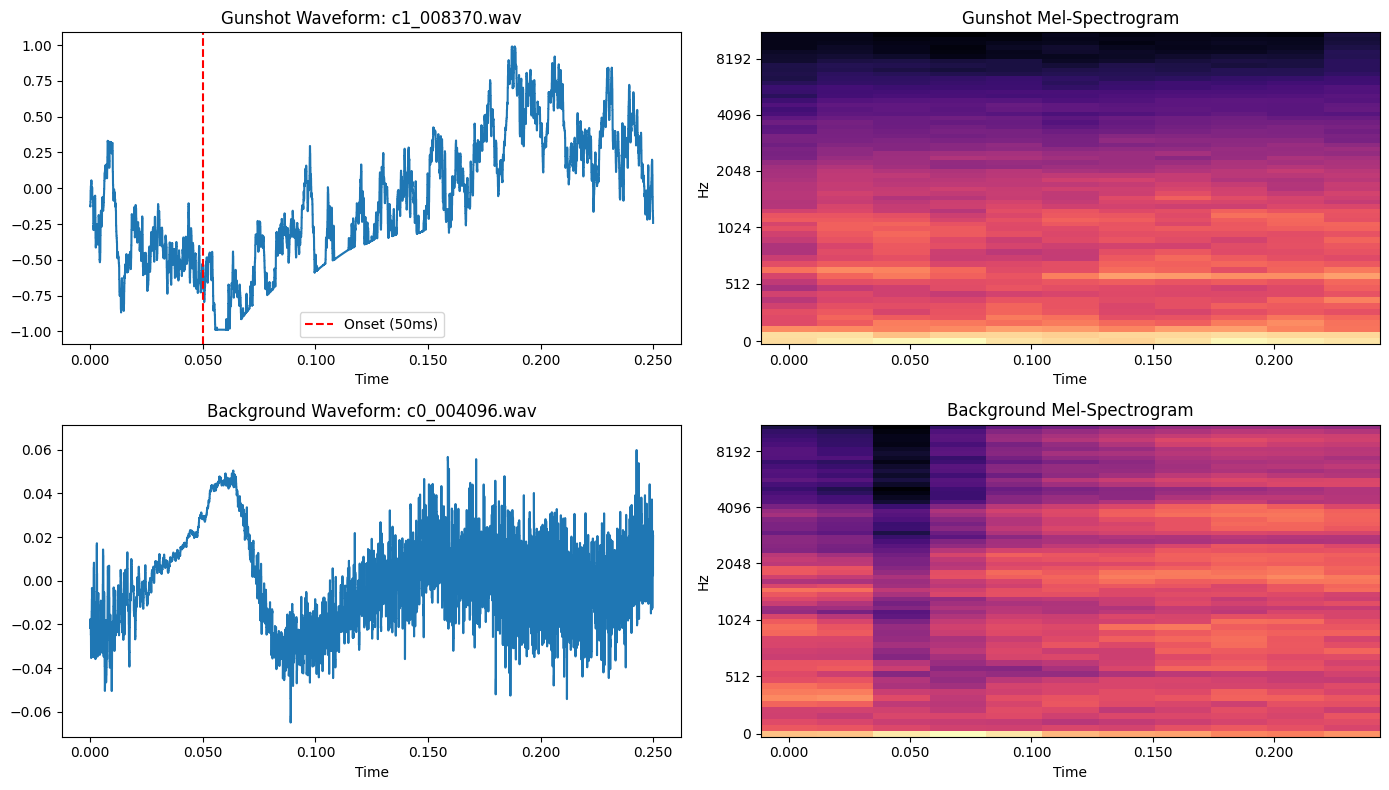

Listen to the gunshot sample:


Listen to the background sample:


In [10]:
# ==========================================================
# VISUAL CHECK: Plot a random gunshot and a random background
# ==========================================================
import IPython.display as ipd

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Random gunshot
c1_sample = random.choice(c1_files)
y1, sr1 = librosa.load(c1_sample, sr=None)
axes[0, 0].set_title(f'Gunshot Waveform: {c1_sample.name}')
librosa.display.waveshow(y1, sr=sr1, ax=axes[0, 0])
axes[0, 0].axvline(x=PRE_EVENT_MS/1000, color='r', linestyle='--', label='Onset (50ms)')
axes[0, 0].legend()

S1 = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=64)
S1_dB = librosa.power_to_db(S1, ref=np.max)
librosa.display.specshow(S1_dB, sr=sr1, x_axis='time', y_axis='mel', ax=axes[0, 1])
axes[0, 1].set_title('Gunshot Mel-Spectrogram')

# Random background
c0_sample = random.choice(c0_files)
y0, sr0 = librosa.load(c0_sample, sr=None)
axes[1, 0].set_title(f'Background Waveform: {c0_sample.name}')
librosa.display.waveshow(y0, sr=sr0, ax=axes[1, 0])

S0 = librosa.feature.melspectrogram(y=y0, sr=sr0, n_mels=64)
S0_dB = librosa.power_to_db(S0, ref=np.max)
librosa.display.specshow(S0_dB, sr=sr0, x_axis='time', y_axis='mel', ax=axes[1, 1])
axes[1, 1].set_title('Background Mel-Spectrogram')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'reports' / 'sample_comparison.png', dpi=150)
plt.show()

print('Listen to the gunshot sample:')
display(ipd.Audio(c1_sample))
print('Listen to the background sample:')
display(ipd.Audio(c0_sample))